In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import h5py

In [2]:
from symmlearn.lattice import RandomLattice, plane2layer
from abtem.visualize import show_atoms
from pyxtal import pyxtal

In [3]:
from pyxtal.symmetry import get_symbol_and_number

In [119]:
import numpy as np
from collections import defaultdict
from typing import List, Tuple
from pyxtal import pyxtal
from ase import Atoms

# your existing layer↔plane maps…

# Mapping from layer‐group number (1–80) to wallpaper (plane)‐group number (1–17)
_lg2pg = {
    1:1,  2:2,  3:2,  4:1,  5:1,  6:2,  7:2,  8:3,  9:4, 10:5,
    11:3, 12:4, 13:5, 14:6, 15:7, 16:7, 17:8, 18:9, 19:6, 20:7,
    21:8, 22:9, 23:6, 24:7, 25:8, 26:9, 27:3, 28:3, 29:4, 30:3,
    31:3, 32:4, 33:4, 34:5, 35:5, 36:3, 37:6, 38:6, 39:10,40:7,
    41:6, 42:9, 43:7, 44:8, 45:7, 46:10,47:9, 48:6, 49:10,50:10,
    51:10,52:12,53:11,54:12,55:11,56:12,57:11,58:12,59:11,60:12,
    61:11,62:11,63:12,64:11,65:13,66:16,67:14,68:15,69:14,70:15,
    71:17,72:17,73:16,74:13,75:16,76:17,77:17,78:14,79:15,80:17
}

_pg2lg = defaultdict(list)
for lg, pg in _lg2pg.items():
    _pg2lg[pg].append(lg)

def plane2layer(pg: int) -> List[int]:
    return sorted(_pg2lg[pg])


# the general-orbit multiplicities
_general_mult = {
    1:  1,
    2:  2,  3:  2,  4:  2,  5:  2,  6:  2,  7:  2,  8:  2,  9:  2,
    10: 4, 11: 4, 12: 4,
    13: 3, 14: 3, 15: 3,
    16: 6,
    17: 12,
}


def generate_atoms(
    plane_group: int,
    seed: int | None = None,
) -> Atoms:
    """
    Build a 2D random structure that *fills the general Wyckoff orbit*
    of the given wallpaper group, so every plane group projects to
    a unique (x,y) pattern.
    """
    # 1) RNG setup (as before)
    ss = np.random.SeedSequence(seed)
    child_seeds = ss.spawn(4)
    rng1 = np.random.default_rng(child_seeds[0])
    rng2 = np.random.default_rng(child_seeds[1])
    rng3 = np.random.default_rng(child_seeds[2])
    rng4 = np.random.default_rng(child_seeds[3])

    # 2) pick a random layer subgroup
    layer_choices = plane2layer(plane_group)
    lg = rng1.choice(layer_choices)

    # 3) figure out how many atoms fill the *general* orbit
    n = _general_mult[plane_group]

    # 4) generate that unit cell in Wyckoff 'a' (general position)
    struct = pyxtal()
    struct.from_random(
        dim=2,
        group=lg,
        species=['C'],
        numIons=[n],       # one atom per general site
        thickness=6.0,
        random_state=rng2
    )
    atoms_uc = struct.to_ase()

    # 5) apply a random rotation in-plane
    angle = rng3.uniform(0, 360)
    atoms_uc.rotate(angle, 'z', rotate_cell=True)

    # 6) repeat a fixed supercell
    return atoms_uc.repeat((5, 5, 1))

In [120]:
atoms1 = generate_atoms(17, 2)
atoms2 = generate_atoms(16, 2)

((<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>),
 (<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>))

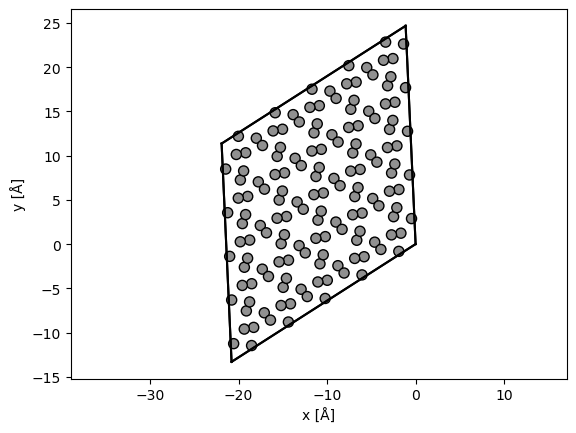

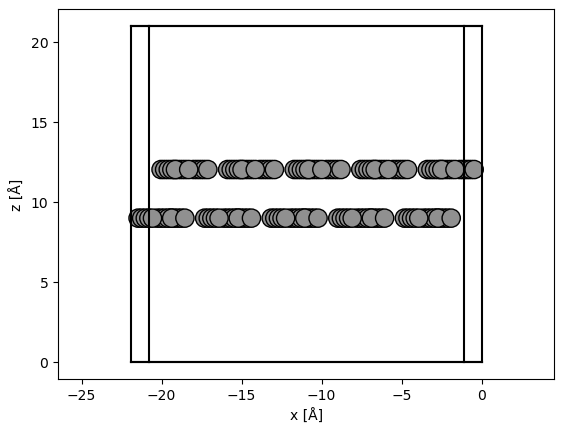

In [122]:
show_atoms(atoms2, plane='xy'), show_atoms(atoms2, plane='xz')

((<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>),
 (<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>))

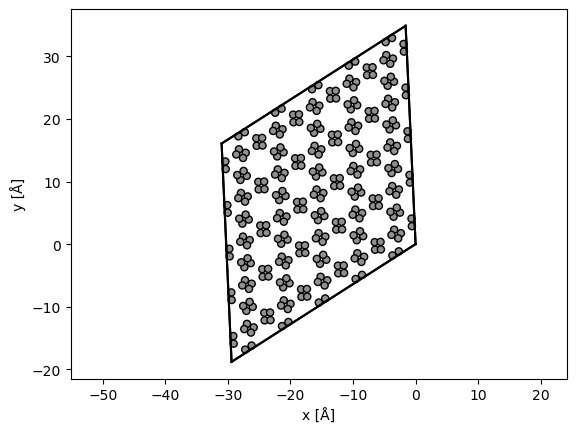

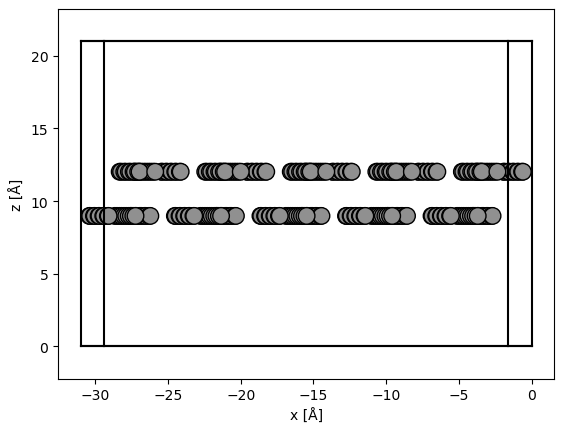

In [121]:
show_atoms(atoms1, plane='xy'), show_atoms(atoms1, plane='xz')

In [98]:
def generate_atoms(plane_group, num_atoms, seed=None):
    # Create a SeedSequence from the main seed
    seed_seq = np.random.SeedSequence(seed)
    
    # Generate independent child seeds
    child_seeds = seed_seq.spawn(4)
    
    # Create independent random generators
    rng1 = np.random.default_rng(child_seeds[0]) # this is for num_atoms_in_unit_cell
    rng2 = np.random.default_rng(child_seeds[1]) # this is for construct random structure
    rng3 = np.random.default_rng(child_seeds[2]) # this is for rotation
    rng4 = np.random.default_rng(child_seeds[3]) # this is for supercell
    
    
    struct = pyxtal()
    _ = struct.from_random(dim=2, group=plane2layer(plane_group)[0],
                                   species=['C'], numIons=[num_atoms],
                                   thickness=6., random_state=rng2)
    atoms_unit_cell = struct.to_ase()
    atoms = atoms_unit_cell * [5, 5, 1]
    return atoms, struct

In [99]:
atoms1, struct1 = generate_atoms(17, 2)
atoms2, struct2 = generate_atoms(16, 2)

In [106]:
struct1.supergroup

<bound method pyxtal.supergroup of 
------Crystal from random------
Dimension: 2
Composition: C2
Group: p-31m (71)
  2.3724,   2.3724,   6.0000,  90.0000,  90.0000, 120.0000, hexagonal
Wyckoff sites:
	 C @ [ 0.0000  0.0000  0.3332], WP [2c] Site m]>

In [109]:
general_letter = struct1.spacegroup_info.general_letter  # e.g. 'a' or 'b'

AttributeError: 'pyxtal' object has no attribute 'spacegroup_info'

((<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>),
 (<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>))

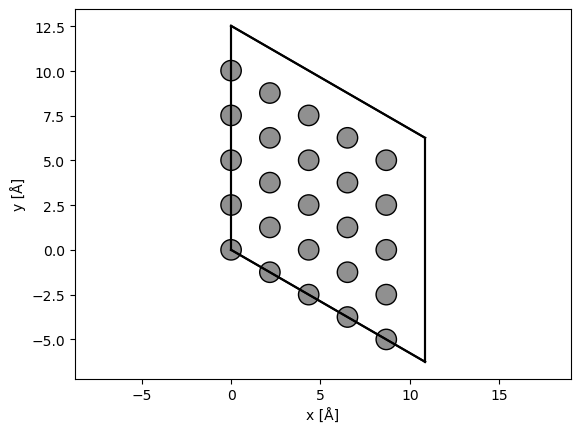

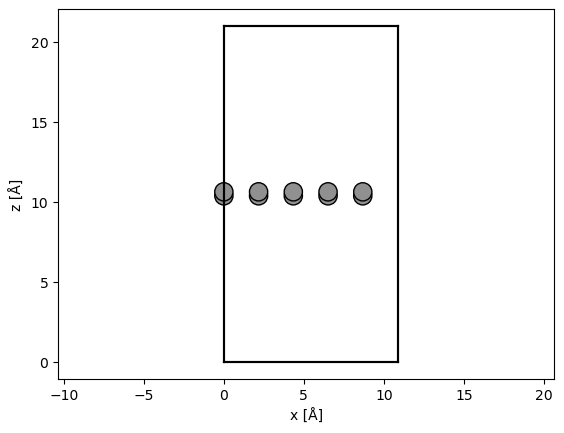

In [95]:
show_atoms(atoms1, plane='xy'), show_atoms(atoms1, plane='xz')

In [30]:
from pyxtal.symmetry import Group

In [33]:
g=Group.list_groups(dim=2)

   layer_group
1           p1
2          p-1
3         p112
4         p11m
5         p11a
6       p112/m
7       p112/a
8         p211
9        p2111
10        c211
11        pm11
12        pb11
13        cm11
14      p2/m11
15     p21/m11
16      p2/b11
17     p21/b11
18      c2/m11
19        p222
20       p2122
21      p21212
22        c222
23        pmm2
24        pma2
25        pba2
26        cmm2
27        pm2m
28       pm21b
29       pb21m
30        pb2b
31        pm2a
32       pm21n
33       pb21a
34        pb2n
35        cm2m
36        cm2e
37        pmmm
38        pmaa
39        pban
40        pmam
41        pmma
42        pman
43        pbaa
44        pbam
45        pbma
46        pmmn
47        cmmm
48        cmme
49          p4
50         p-4
51        p4/m
52        p4/n
53        p422
54       p4212
55        p4mm
56        p4bm
57       p-42m
58      p-421m
59       p-4m2
60       p-4b2
61      p4/mmm
62      p4/nbm
63      p4/mbm
64      p4/nmm
65          p3
66        

In [15]:
wallpaper = ["p1","p2","p2mm","p3","p3m1","p31m","p4","p4mm","p6","p6mm"]
for sym in wallpaper:
    print(sym, get_symbol_and_number(sym, dim=2))

I have this error: ValueError: (p2) not found in layer_group 

p1 ('p1', 1)


ValueError: (p2) not found in layer_group 

In [21]:
from pyxtal.symmetry import get_symbol_and_number

# 1. Full Hermann–Mauguin symbols for the 17 wallpaper groups
_wp_full = [
    "p1",   #  1
    "p2",   #  2
    "p1m1", #  3 (pm)
    "p1g1", #  4 (pg)
    "c1m1", #  5 (cm)
    "p2mm", #  6 (pmm)
    "p2mg", #  7 (pmg)
    "p2gg", #  8 (pgg)
    "c2mm", #  9 (cmm)
    "p4",   # 10
    "p4mm", # 11 (p4m)
    "p4gm", # 12 (p4g)
    "p3",   # 13
    "p3m1", # 14
    "p31m", # 15
    "p6",   # 16
    "p6mm", # 17
]

def wallpaper_to_layer(wp_num: int) -> int:
    """
    Map a wallpaper‐group number (1–17) to a PyXtal layer‐group number (1–80).
    """
    if not (1 <= wp_num <= len(_wp_full)):
        raise ValueError(f"Wallpaper group number must be 1–17, got {wp_num}")
    symbol = _wp_full[wp_num - 1]
    # look up in PyXtal’s layer_group list
    _, layer_num = get_symbol_and_number(symbol, dim=2)
    return layer_num

# Example
print(wallpaper_to_layer(3))  # → 77, since 'p6mm' is layer group #77


ValueError: (p1m1) not found in layer_group 

In [134]:
aa = RandomLattice()
lattice = aa.generate_lattice(16, num_atoms=2, seed=None)
kk = aa.generate_data(lattice, sigma=5, size=512)

In [136]:
np.save('lattice_image.npy', kk)

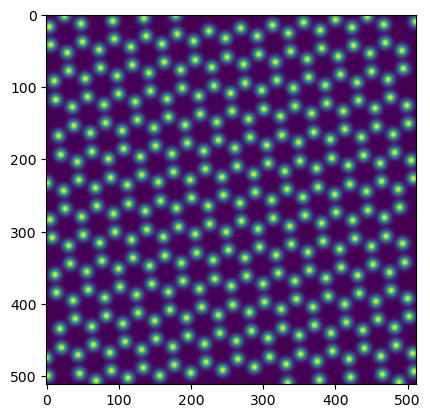

In [135]:
plt.imshow(kk)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

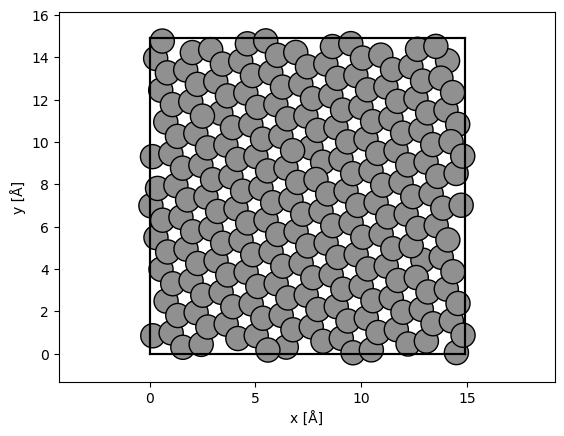

In [125]:
show_atoms(lattice, plane='xy')

In [ ]:
# define random crystal
struct = pyxtal()

In [37]:
_ = struct.from_random(dim=2, group=77,
                       species=['C'], numIons=[4],
                       thickness=10.)
atoms_unit_cell = struct.to_ase()

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

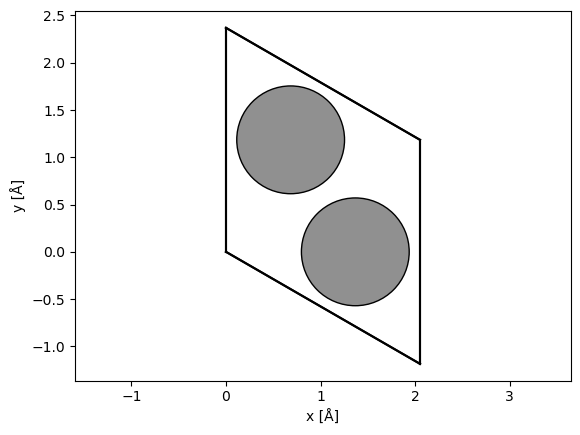

In [38]:
show_atoms(atoms_unit_cell * [1, 1, 1], plane='xy')

In [39]:
atoms_unit_cell.get_positions()

array([[6.83921549e-01, 1.18458687e+00, 8.61865264e+00],
       [1.36784310e+00, 2.22044605e-16, 8.61865264e+00],
       [6.83921549e-01, 1.18458687e+00, 1.28889830e+01],
       [1.36784310e+00, 2.22044605e-16, 1.28889830e+01]])

In [41]:
import numpy as np

def has_duplicate_xy_vec(points: np.ndarray) -> bool:
    """
    Vectorized check for duplicate (x, y) pairs.
    """
    # take only x,y columns
    xy = points[:, :2]
    # convert each row to a single bytes object, then count uniques
    dtype = np.dtype((np.void, xy.dtype.itemsize * xy.shape[1]))
    packed = np.ascontiguousarray(xy).view(dtype)
    _, counts = np.unique(packed, return_counts=True)
    return np.any(counts > 1)

# Example
print(has_duplicate_xy_vec(atoms_unit_cell.get_positions()))  # → True


True


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

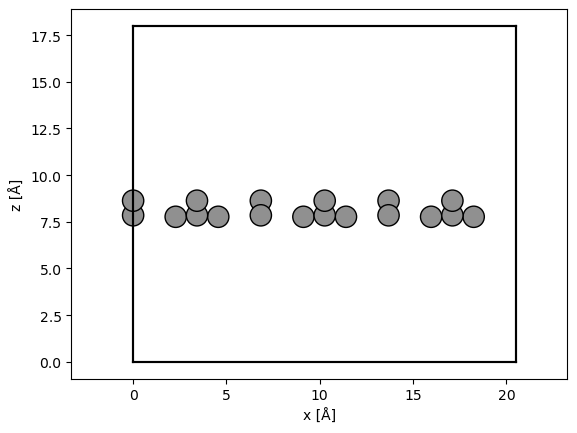

In [218]:
show_atoms(atoms_unit_cell * [3, 3, 1], plane='xz')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

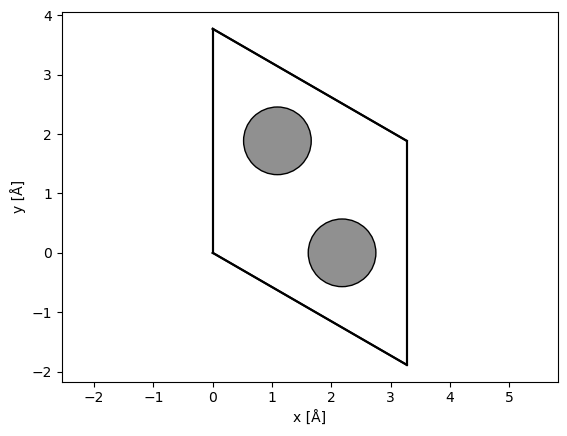

In [15]:
show_atoms(aa.atoms_unit_cell)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

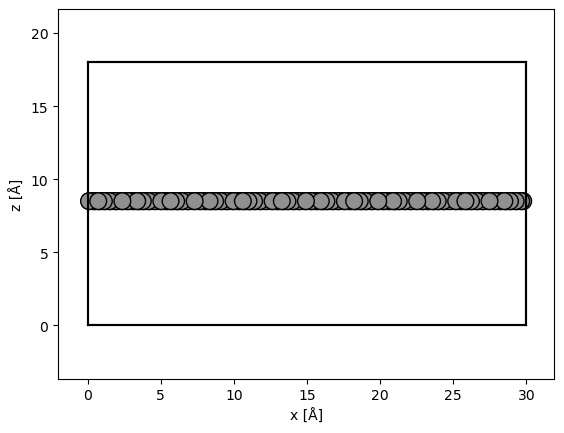

In [34]:
show_atoms(lattice, plane='xz')

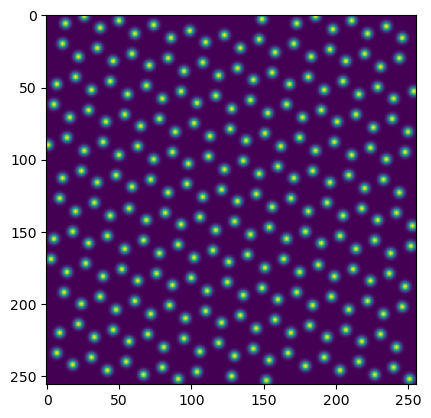

In [32]:
plt.imshow(kk)

In [27]:
from ase.visualize.plot import plot_atoms

In [28]:
from abtem.visualize import show_atoms
show_atoms(lattice, plane='xz')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

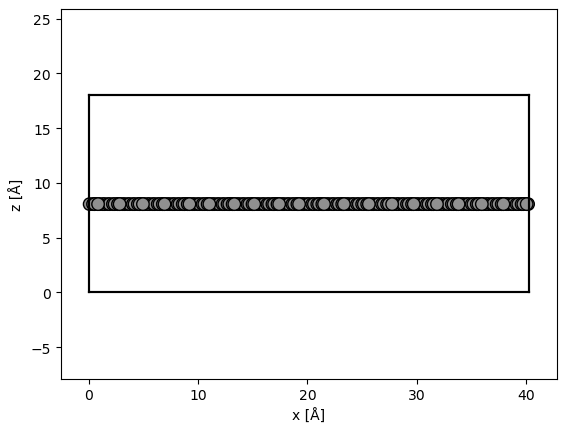

In [29]:
show_atoms(lattice, plane='xz')

<Axes: >

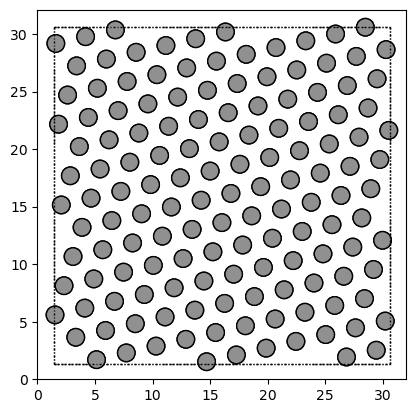

In [18]:
plot_atoms(lattice)

## generate tiny dataset

In [31]:
X = []
y = []
num_imgs = 500
aa = RandomLattice()
for i in tqdm(range(1, 18)):
    for j in range(num_imgs):
        lattice = aa.generate_lattice(i, seed=None)
        kk = aa.generate_data(lattice, sigma=2, size=256).astype(np.float32)
        X.append(kk)
        y.append(i)
X = np.array(X)
y = np.array(y)

  0%|                                                                                           | 0/17 [00:00<?, ?it/s]C:\Users\jiadong\miniconda3\envs\jiadong\Lib\site-packages\pyxtal\crystal.py:248: UserWarning: Warning: increase the volume by 1.1 times: 3.87
  warn(f"Warning: increase the volume by 1.1 times: {self.volume:.2f}")
C:\Users\jiadong\miniconda3\envs\jiadong\Lib\site-packages\pyxtal\crystal.py:248: UserWarning: Warning: increase the volume by 1.1 times: 3.28
  warn(f"Warning: increase the volume by 1.1 times: {self.volume:.2f}")
C:\Users\jiadong\miniconda3\envs\jiadong\Lib\site-packages\pyxtal\crystal.py:248: UserWarning: Warning: increase the volume by 1.1 times: 2.51
  warn(f"Warning: increase the volume by 1.1 times: {self.volume:.2f}")
C:\Users\jiadong\miniconda3\envs\jiadong\Lib\site-packages\pyxtal\crystal.py:248: UserWarning: Warning: increase the volume by 1.1 times: 2.76
  warn(f"Warning: increase the volume by 1.1 times: {self.volume:.2f}")
C:\Users\jiadong\mini

In [32]:
# Assume X, y have been loaded already (e.g. via np.load)
# 0) Ensure correct dtypes
X = X.astype(np.float32)
y = y.astype(np.int64)

# 1) Shuffle
rng = np.random.default_rng(seed=42)  # seed for reproducibility
perm = rng.permutation(len(X))
X_shuffled = X[perm]
y_shuffled = y[perm]

# 2) Split
train_ratio = 0.8
n_train = int(len(X_shuffled) * train_ratio)

X_train = X_shuffled[:n_train]
y_train = y_shuffled[:n_train]
X_test  = X_shuffled[n_train:]
y_test  = y_shuffled[n_train:]

# 3) Save to HDF5
with h5py.File('symmetry_dataset_{}_per_class.h5'.format(num_imgs), 'w') as f:
    grp_train = f.create_group('train')
    grp_test  = f.create_group('test')

    grp_train.create_dataset('X', data=X_train,
                             dtype='float32',
                             compression='gzip',
                             compression_opts=4)
    grp_train.create_dataset('y', data=y_train,
                             dtype='int64',
                             compression='gzip',
                             compression_opts=4)

    grp_test.create_dataset('X', data=X_test,
                            dtype='float32',
                            compression='gzip',
                            compression_opts=4)
    grp_test.create_dataset('y', data=y_test,
                            dtype='int64',
                            compression='gzip',
                            compression_opts=4)

print("Done: ensured types, shuffled, split, and saved to defect_dataset.h5")

Done: ensured types, shuffled, split, and saved to defect_dataset.h5
